In [1]:
"""
Notebook to generate IEC-style 2D (wsp, TI) joint distributions for use in IEC baseline mode.

Output:
- CSV file for each IEC class (e.g., IEC_classIA_distribution.csv)
- Optional: heatmap plot of the joint probability distribution
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gamma  # Required for Weibull scale calculation

import numpy as np
import pandas as pd
from scipy.special import gamma
from pathlib import Path

def generate_iec_distribution(iec_class, wsp_centers, output_path, save_metadata=False):
    """
    Generate IEC 61400-1 compliant (wsp, TI) joint distribution with one TI per wind speed.

    Output: CSV with columns wsp, TI, probability (probability from Rayleigh, TI from IEC formula)
    """
    props = IEC_CLASSES[iec_class]
    Vave = props["Vave"]
    Vref = props["Vref"]
    TIref = props["TIref"]

    # --- Rayleigh PDF for wind speed ---
    def rayleigh_pdf(v, v_ave):
        A = v_ave * np.sqrt(2 / np.pi)
        return (v / A**2) * np.exp(-(v**2) / (2 * A**2))

    wsp_pdf = rayleigh_pdf(wsp_centers, Vave)
    wsp_pdf /= wsp_pdf.sum()

    # --- TI from IEC equation ---
    TI_values = TIref * (0.75 + 0.25 * 15 / wsp_centers)

    # --- Create record ---
    records = []
    for wsp, TI, prob in zip(wsp_centers, TI_values, wsp_pdf):
        records.append({
            "wsp": round(wsp, 4),
            "TI": round(TI, 4),
            "probability": round(prob, 5)
        })

    df = pd.DataFrame(records)

    # Save CSV
    filename = output_path / f"IEC_{iec_class}_distribution.csv"
    # df.to_csv(filename, index=False, float_format="%.5f")
    print(f"Saved {filename}")

    # Save metadata
    if save_metadata:
        import json
        meta = {"Vave": Vave, "Vref": Vref, "TIref": TIref}
        with open(output_path / f"IEC_{iec_class}_meta.json", "w") as f:
            json.dump(meta, f, indent=2)

    return df


In [2]:
# Definitions 

# Define output folder
output_folder = Path("./distributions") 
output_folder.mkdir(exist_ok=True)

# Define wind speed bins (e.g., from 4 to 26 m/s)
wsp_bins = np.arange(3, 25.5, 0.5)  # edges: 4, 6, ..., 24
wsp_centers = (wsp_bins[:-1] + wsp_bins[1:]) / 2

IEC_CLASSES = {
    "IA+":   {"Vave": 10.0, "Vref": 50.0, "TIref": 0.18},
    "IA":   {"Vave": 10.0, "Vref": 50.0, "TIref": 0.16},
    "IB":   {"Vave": 10.0, "Vref": 50.0, "TIref": 0.14},
    "IC":   {"Vave": 10.0, "Vref": 50.0, "TIref": 0.12},
    "IIA+":  {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.18},
    "IIA":  {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.16},
    "IIB":  {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.14},
    "IIC":  {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.12},
    "IIIA+": {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.18},
    "IIIA": {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.16},
    "IIIB": {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.14},
    "IIIC": {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.12},
    "IVA+":  {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.18},
    "IVA":  {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.16},
    "IVB":  {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.14},
    "IVC":  {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.12},
}


for iec_class in IEC_CLASSES:

    # Generate and save
    df_ia = generate_iec_distribution(iec_class, wsp_centers, output_folder)

Saved distributions/IEC_IA+_distribution.csv
Saved distributions/IEC_IA_distribution.csv
Saved distributions/IEC_IB_distribution.csv
Saved distributions/IEC_IC_distribution.csv
Saved distributions/IEC_IIA+_distribution.csv
Saved distributions/IEC_IIA_distribution.csv
Saved distributions/IEC_IIB_distribution.csv
Saved distributions/IEC_IIC_distribution.csv
Saved distributions/IEC_IIIA+_distribution.csv
Saved distributions/IEC_IIIA_distribution.csv
Saved distributions/IEC_IIIB_distribution.csv
Saved distributions/IEC_IIIC_distribution.csv
Saved distributions/IEC_IVA+_distribution.csv
Saved distributions/IEC_IVA_distribution.csv
Saved distributions/IEC_IVB_distribution.csv
Saved distributions/IEC_IVC_distribution.csv


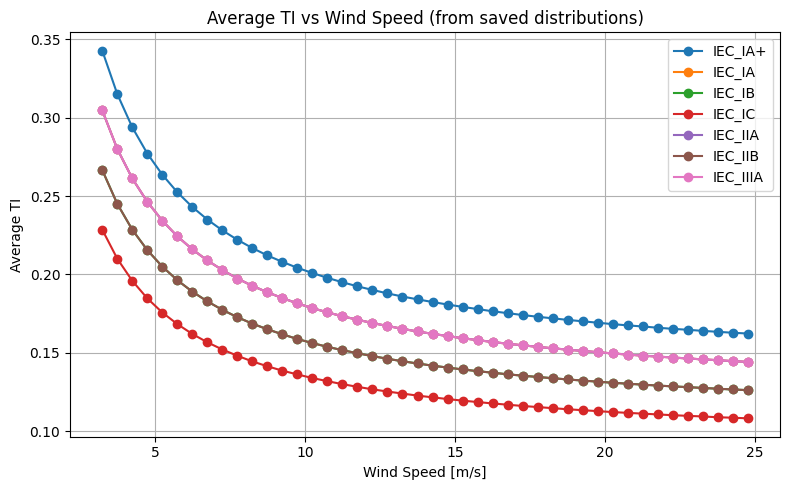

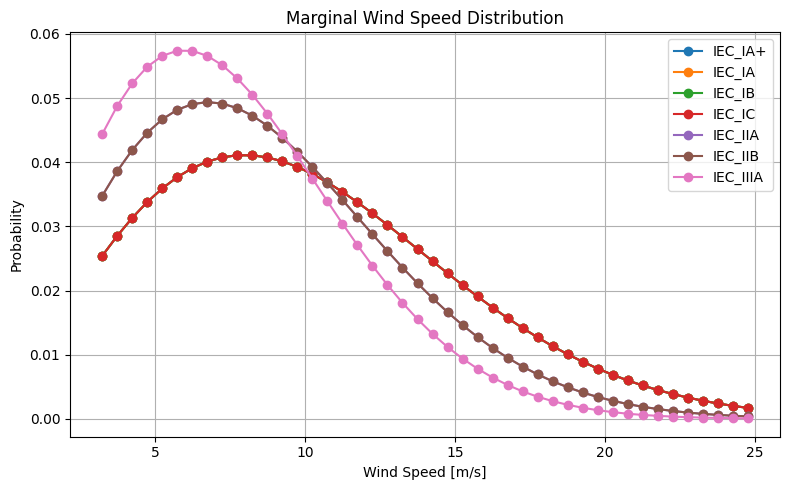

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Define folder and file names
distribution_folder = Path("distributions")
selected_files = [
    "IEC_IA+_distribution.csv",
    "IEC_IA_distribution.csv",
    "IEC_IB_distribution.csv",
    "IEC_IC_distribution.csv",
    "IEC_IIA_distribution.csv",
    "IEC_IIB_distribution.csv",
    "IEC_IIIA_distribution.csv"
]

# --- Plot 1: Average TI vs Wind Speed ---
plt.figure(figsize=(8, 5))
for fname in selected_files:
    df = pd.read_csv(distribution_folder / fname)

    # Compute weighted average TI for each wind speed
    avg_ti = df.set_index("wsp")["TI"]


    label = fname.replace("_distribution.csv", "")
    plt.plot(avg_ti.index, avg_ti.values, marker='o', label=label)

plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Average TI")
plt.title("Average TI vs Wind Speed (from saved distributions)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Marginal Wind Speed Probability ---
plt.figure(figsize=(8, 5))
for fname in selected_files:
    df = pd.read_csv(distribution_folder / fname)
    marginal_wsp = df.groupby("wsp")["probability"].sum()

    label = fname.replace("_distribution.csv", "")
    plt.plot(marginal_wsp.index, marginal_wsp.values, marker='o', label=label)

plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Probability")
plt.title("Marginal Wind Speed Distribution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
